# Seasonal Agriculture Performance Analysis

In [26]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

try:
    import seaborn as sns
    HAS_SEABORN = True
except Exception:
    HAS_SEABORN = False

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

FILE_NAME = "seasonal_agriculture_performance_dataset.csv"

candidates = []
cwd = Path.cwd()

for base in [cwd, *cwd.parents]:
    candidates.append(base / FILE_NAME)
    candidates.extend(base.glob(f"*/{FILE_NAME}"))
    candidates.extend(base.glob(f"*/data/{FILE_NAME}"))

seen = set()
candidates = [p for p in candidates if not (str(p) in seen or seen.add(str(p)))]

DATA_PATH = next((p for p in candidates if p.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        f"Could not find '{FILE_NAME}'. Put the CSV in the same folder as this notebook "
        "or in a nearby data folder, then run this cell again."
    )

PROJECT_DIR = DATA_PATH.parent
OUTPUT_DIR = PROJECT_DIR / "outputs"
CHART_DIR = OUTPUT_DIR / "charts"
TABLE_DIR = OUTPUT_DIR / "summary_tables"

CHART_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print("CSV found:", DATA_PATH.resolve())
print("Output folder:", OUTPUT_DIR.resolve())

CSV found: C:\Users\Admin\h\seasonal_agriculture_performance_dataset.csv
Output folder: C:\Users\Admin\h\outputs


In [27]:
# 2. LOAD DATASET
df = pd.read_csv(DATA_PATH)

print(f"Dataset loaded successfully: {df.shape[0]:,} rows × {df.shape[1]} columns")
display(df.head())

Dataset loaded successfully: 4,000 rows × 28 columns


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [28]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
missing_initial = df.isna().sum().to_frame("missing")
display(missing_initial[missing_initial["missing"] > 0])

print("\nDuplicate rows:", df.duplicated().sum())

print("\nDescriptive statistics:")
display(df.describe(include="all").T)

Shape: (4000, 28)

Columns:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Data types:


,dtype
Farm_ID,str
State,str
District,str
Crop,str
Season,str
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64



Missing values:


,missing
Rainfall_mm,48
Soil_Moisture_pct,40
Yield_Tonnes_Ha,32



Duplicate rows: 0

Descriptive statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Farm_ID,4000,4000,SF10001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,4000,8,Andhra Pradesh,529,NaN,NaN,NaN,NaN,NaN,NaN,NaN
District,4000,10,Ludhiana,427,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crop,4000,8,Rice,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Season,4000,3,Kharif,1779,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Farm_Area_Hectares,"4,000.00",NaN,NaN,NaN,7.89,4.22,0.50,4.26,7.89,11.65,15.00
Rainfall_mm,"3,952.00",NaN,NaN,NaN,601.15,288.93,80.00,370.20,582.00,834.95,"1,395.20"
Avg_Temperature_C,"4,000.00",NaN,NaN,NaN,26.82,3.82,16.20,23.90,26.90,29.60,39.70
Humidity_pct,"4,000.00",NaN,NaN,NaN,63.21,11.96,25.00,54.77,63.00,71.90,95.00
Sunlight_Hours_Day,"4,000.00",NaN,NaN,NaN,7.32,1.12,3.50,6.60,7.30,8.10,11.00


In [30]:
# 4. DATA CLEANING AND PREPARATION
data = df.copy()

# Strip whitespace from text fields
object_cols = data.select_dtypes(include="object").columns
for col in object_cols:
    data[col] = data[col].astype("string").str.strip()

# Convert all expected numeric columns explicitly
numeric_columns = [
    "Farm_Area_Hectares", "Rainfall_mm", "Avg_Temperature_C",
    "Humidity_pct", "Sunlight_Hours_Day", "Soil_pH",
    "Soil_Moisture_pct", "Nitrogen_kg_ha", "Phosphorus_kg_ha",
    "Potassium_kg_ha", "Fertilizer_kg_ha", "Pesticide_Litre_ha",
    "Seed_Quality_Score", "Yield_Tonnes_Ha", "Production_Tonnes",
    "Market_Price_INR_Tonne", "Total_Cost_INR", "Revenue_INR",
    "Profit_INR", "Water_Used_m3",
    "Water_Efficiency_t_per_1000m3", "Disease_Pest_Risk_pct"
]

for col in numeric_columns:
    if col in data.columns:
        data[col] = pd.to_numeric(data[col], errors="coerce")

missing_before = int(data.isna().sum().sum())
duplicates_before = int(data.duplicated().sum())

# Median imputation for numeric variables
for col in data.select_dtypes(include=np.number).columns:
    data[col] = data[col].fillna(data[col].median())

# Explicit Unknown for missing categorical values
for col in data.select_dtypes(include="string").columns:
    data[col] = data[col].fillna("Unknown")

# Remove duplicate records
data = data.drop_duplicates().reset_index(drop=True)

quality = pd.DataFrame({
    "Metric": [
        "Rows before cleaning",
        "Rows after cleaning",
        "Duplicate rows before cleaning",
        "Duplicate rows removed",
        "Missing cells before cleaning",
        "Missing cells after cleaning"
    ],
    "Value": [
        len(df),
        len(data),
        duplicates_before,
        duplicates_before - int(data.duplicated().sum()),
        missing_before,
        int(data.isna().sum().sum())
    ]
})

display(quality)
print(f"Clean dataset: {len(data):,} rows × {len(data.columns)} columns")

,Metric,Value
0,Rows before cleaning,4000
1,Rows after cleaning,4000
2,Duplicate rows before cleaning,0
3,Duplicate rows removed,0
4,Missing cells before cleaning,120
5,Missing cells after cleaning,0


Clean dataset: 4,000 rows × 28 columns


In [31]:
# 5. CLEAN DATA VALIDATION
required_columns = [
    "Farm_ID","State","District","Crop","Season","Farm_Area_Hectares",
    "Rainfall_mm","Avg_Temperature_C","Humidity_pct","Sunlight_Hours_Day",
    "Soil_pH","Soil_Moisture_pct","Nitrogen_kg_ha","Phosphorus_kg_ha",
    "Potassium_kg_ha","Irrigation_Method","Fertilizer_kg_ha",
    "Pesticide_Litre_ha","Seed_Quality_Score","Yield_Tonnes_Ha",
    "Production_Tonnes","Market_Price_INR_Tonne","Total_Cost_INR",
    "Revenue_INR","Profit_INR","Water_Used_m3",
    "Water_Efficiency_t_per_1000m3","Disease_Pest_Risk_pct"
]

missing_required = [c for c in required_columns if c not in data.columns]

if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

print("Clean data shape:", data.shape)
print("Seasons:", sorted(data["Season"].dropna().unique().tolist()))
print("Number of seasons:", data["Season"].nunique())
print("Crops:", sorted(data["Crop"].dropna().unique().tolist()))
print("Number of crops:", data["Crop"].nunique())
print("States:", sorted(data["State"].dropna().unique().tolist()))
print("Number of states:", data["State"].nunique())
print("Remaining missing cells:", int(data.isna().sum().sum()))

display(data.head())

Clean data shape: (4000, 28)
Seasons: ['Kharif', 'Rabi', 'Zaid']
Number of seasons: 3
Crops: ['Chilli', 'Cotton', 'Groundnut', 'Maize', 'Pulses', 'Rice', 'Sugarcane', 'Wheat']
Number of crops: 8
States: ['Andhra Pradesh', 'Gujarat', 'Karnataka', 'Madhya Pradesh', 'Maharashtra', 'Punjab', 'Tamil Nadu', 'Telangana']
Number of states: 8
Remaining missing cells: 0


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


## 6. Season-wise Performance Analysis

In [35]:
# 6. SEASON-WISE KPI ANALYSIS
season_kpi = (
    data.groupby("Season", dropna=False)
    .agg(
        Records=("Farm_ID", "count"),
        Avg_Yield=("Yield_Tonnes_Ha", "mean"),
        Total_Production=("Production_Tonnes", "sum"),
        Total_Revenue=("Revenue_INR", "sum"),
        Total_Cost=("Total_Cost_INR", "sum"),
        Total_Profit=("Profit_INR", "sum"),
        Avg_Water_Used=("Water_Used_m3", "mean"),
        Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
        Avg_Risk=("Disease_Pest_Risk_pct", "mean")
    )
    .reset_index()
)

season_kpi["Profit_Margin_pct"] = np.where(
    season_kpi["Total_Revenue"].ne(0),
    season_kpi["Total_Profit"] / season_kpi["Total_Revenue"] * 100,
    np.nan
)

season_kpi = season_kpi.sort_values("Total_Profit", ascending=False).reset_index(drop=True)

display(season_kpi.round(2))

print("Validation:")
print("KPI rows:", len(season_kpi))
print("Total records represented:", int(season_kpi["Records"].sum()))

,Season,Records,Avg_Yield,Total_Production,Total_Revenue,Total_Cost,Total_Profit,Avg_Water_Used,Avg_Water_Efficiency,Avg_Risk,Profit_Margin_pct
0,Kharif,1779,5.63,"82,387.61",1264369200,946080042,318289158,"6,102.20",5.89,54.47,25.17
1,Rabi,1627,5.04,"67,498.88",978682881,836012113,142670768,"5,846.99",5.19,40.48,14.58
2,Zaid,594,4.64,"23,098.35",308388111,323122177,-14734066,"6,419.89",4.41,38.22,-4.78


Validation:
KPI rows: 3
Total records represented: 4000


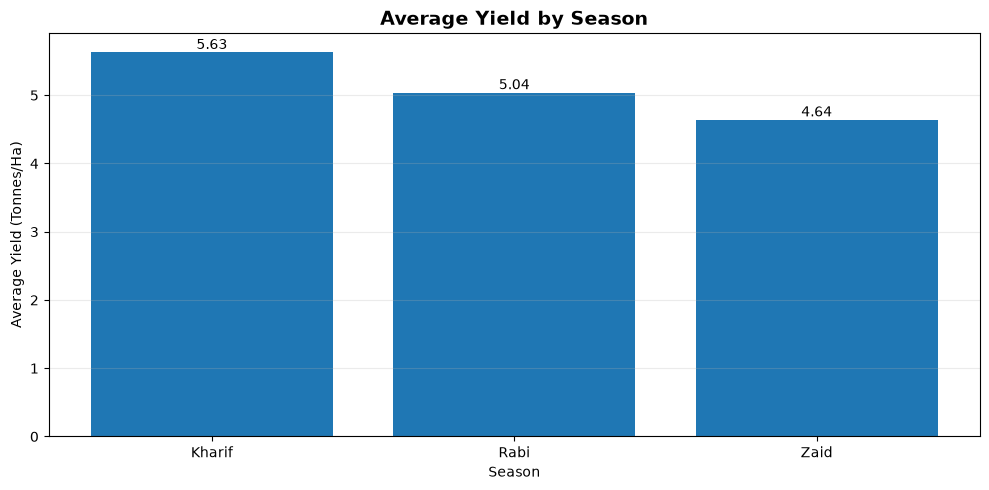

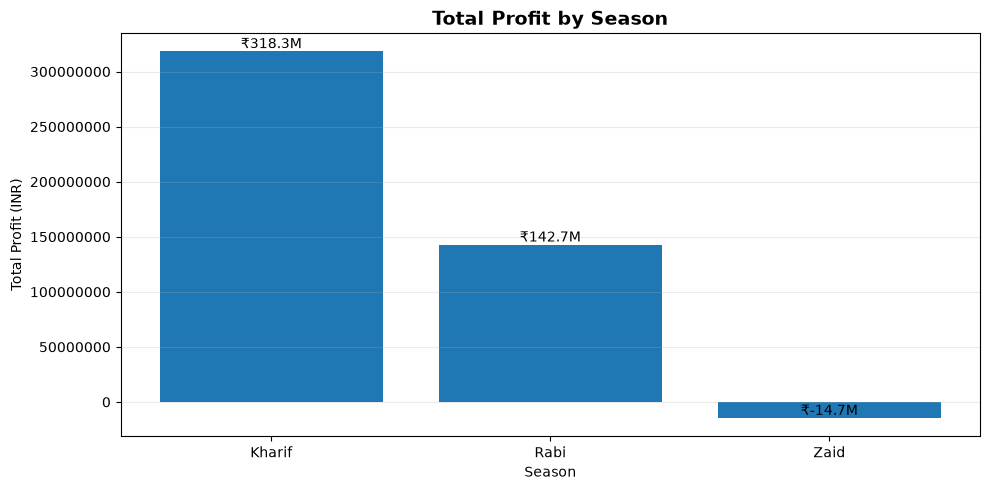

Season charts saved to: C:\Users\Admin\h\outputs\charts


In [36]:
# 7. SEASON-WISE VISUALIZATIONS

# Chart 1: Average Yield by Season
plt.figure(figsize=(10, 5))
bars = plt.bar(season_kpi["Season"], season_kpi["Avg_Yield"])
plt.title("Average Yield by Season", fontsize=14, fontweight="bold")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.grid(axis="y", alpha=0.25)

for bar, value in zip(bars, season_kpi["Avg_Yield"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f"{value:.2f}", ha="center", va="bottom")

plt.tight_layout()
plt.savefig(CHART_DIR / "01_average_yield_by_season.png", dpi=160, bbox_inches="tight")
plt.show()
plt.close()

# Chart 2: Total Profit by Season
plt.figure(figsize=(10, 5))
bars = plt.bar(season_kpi["Season"], season_kpi["Total_Profit"])
plt.title("Total Profit by Season", fontsize=14, fontweight="bold")
plt.xlabel("Season")
plt.ylabel("Total Profit (INR)")
plt.grid(axis="y", alpha=0.25)
plt.ticklabel_format(style="plain", axis="y")

for bar, value in zip(bars, season_kpi["Total_Profit"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f"₹{value/1e6:.1f}M", ha="center", va="bottom")

plt.tight_layout()
plt.savefig(CHART_DIR / "02_total_profit_by_season.png", dpi=160, bbox_inches="tight")
plt.show()
plt.close()

print("Season charts saved to:", CHART_DIR.resolve())

## 8. Crop-wise Performance Analysis

In [37]:
# 8. CROP-WISE KPI ANALYSIS
crop_kpi = (
    data.groupby("Crop", dropna=False)
    .agg(
        Records=("Farm_ID", "count"),
        Avg_Yield=("Yield_Tonnes_Ha", "mean"),
        Total_Production=("Production_Tonnes", "sum"),
        Total_Revenue=("Revenue_INR", "sum"),
        Total_Cost=("Total_Cost_INR", "sum"),
        Total_Profit=("Profit_INR", "sum"),
        Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
        Avg_Risk=("Disease_Pest_Risk_pct", "mean")
    )
    .reset_index()
)

crop_kpi["Profit_Margin_pct"] = np.where(
    crop_kpi["Total_Revenue"].ne(0),
    crop_kpi["Total_Profit"] / crop_kpi["Total_Revenue"] * 100,
    np.nan
)

crop_kpi = crop_kpi.sort_values("Total_Profit", ascending=False).reset_index(drop=True)

print("Top crops by average yield:")
display(crop_kpi.sort_values("Avg_Yield", ascending=False).head(10).round(2))

print("Top crops by total profit:")
display(crop_kpi.sort_values("Total_Profit", ascending=False).head(10).round(2))

Top crops by average yield:


,Crop,Records,Avg_Yield,Total_Production,Total_Revenue,Total_Cost,Total_Profit,Avg_Water_Efficiency,Avg_Risk,Profit_Margin_pct
1,Sugarcane,305,46.64,"119,685.97",418453935,169211599,249242336,30.48,45.40,59.56
5,Maize,551,2.71,"12,001.40",251844463,298116521,-46272058,5.60,45.54,-18.37
6,Rice,690,2.43,"13,309.15",292294529,362821847,-70527318,1.95,46.50,-24.13
7,Wheat,614,2.11,"10,348.30",245664400,321430979,-75766579,4.63,47.85,-30.84
0,Chilli,412,1.54,"5,101.75",526032218,216670341,309361877,2.95,46.06,58.81
3,Groundnut,424,1.32,"4,094.07",230204651,211184808,19019843,3.15,46.29,8.26
2,Cotton,508,1.23,"4,773.10",324826926,261557093,63269833,1.94,45.97,19.48
4,Pulses,496,0.92,"3,671.10",262119070,264221144,-2102074,2.90,46.57,-0.80


Top crops by total profit:


,Crop,Records,Avg_Yield,Total_Production,Total_Revenue,Total_Cost,Total_Profit,Avg_Water_Efficiency,Avg_Risk,Profit_Margin_pct
0,Chilli,412,1.54,"5,101.75",526032218,216670341,309361877,2.95,46.06,58.81
1,Sugarcane,305,46.64,"119,685.97",418453935,169211599,249242336,30.48,45.40,59.56
2,Cotton,508,1.23,"4,773.10",324826926,261557093,63269833,1.94,45.97,19.48
3,Groundnut,424,1.32,"4,094.07",230204651,211184808,19019843,3.15,46.29,8.26
4,Pulses,496,0.92,"3,671.10",262119070,264221144,-2102074,2.90,46.57,-0.80
5,Maize,551,2.71,"12,001.40",251844463,298116521,-46272058,5.60,45.54,-18.37
6,Rice,690,2.43,"13,309.15",292294529,362821847,-70527318,1.95,46.50,-24.13
7,Wheat,614,2.11,"10,348.30",245664400,321430979,-75766579,4.63,47.85,-30.84


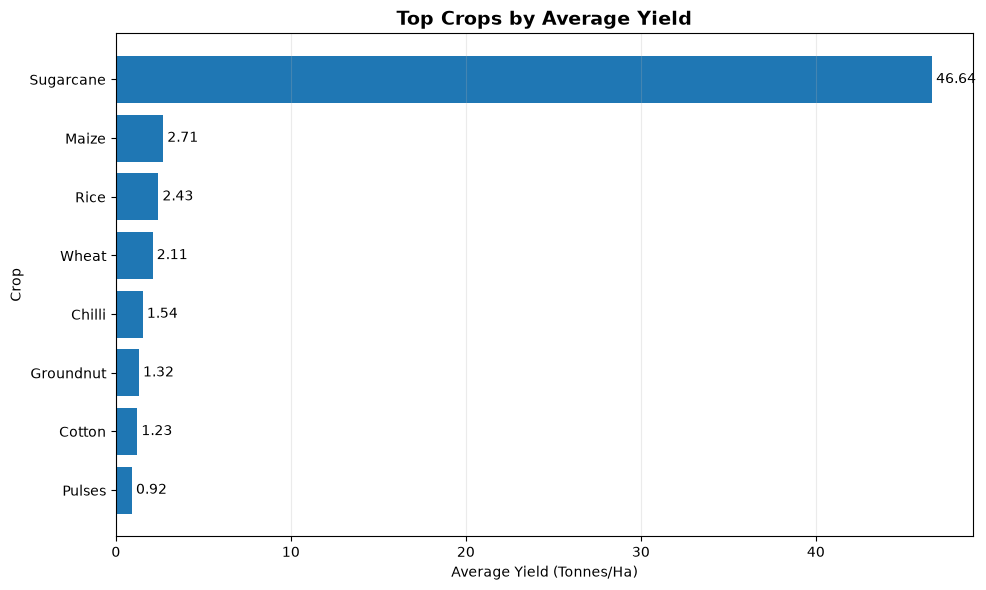

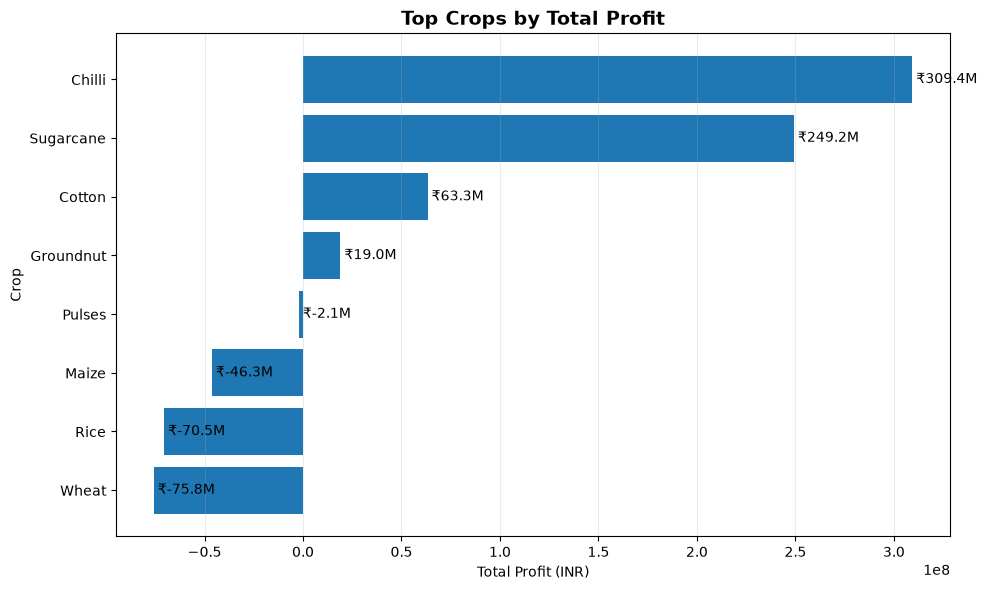

In [38]:
# 9. CROP VISUALIZATIONS
# Average yield
top_yield = crop_kpi.nlargest(10, "Avg_Yield").sort_values("Avg_Yield")

plt.figure(figsize=(10, 6))
bars = plt.barh(top_yield["Crop"], top_yield["Avg_Yield"])
plt.title("Top Crops by Average Yield", fontsize=14, fontweight="bold")
plt.xlabel("Average Yield (Tonnes/Ha)")
plt.ylabel("Crop")
plt.grid(axis="x", alpha=0.25)

for bar, value in zip(bars, top_yield["Avg_Yield"]):
    plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
             f" {value:.2f}", va="center")

plt.tight_layout()
plt.savefig(CHART_DIR / "03_top_crops_yield.png", dpi=160, bbox_inches="tight")
plt.show()
plt.close()

# Total profit
top_profit = crop_kpi.nlargest(10, "Total_Profit").sort_values("Total_Profit")

plt.figure(figsize=(10, 6))
bars = plt.barh(top_profit["Crop"], top_profit["Total_Profit"])
plt.title("Top Crops by Total Profit", fontsize=14, fontweight="bold")
plt.xlabel("Total Profit (INR)")
plt.ylabel("Crop")
plt.grid(axis="x", alpha=0.25)

for bar, value in zip(bars, top_profit["Total_Profit"]):
    plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
             f" ₹{value/1e6:.1f}M", va="center")

plt.tight_layout()
plt.savefig(CHART_DIR / "04_top_crops_profit.png", dpi=160, bbox_inches="tight")
plt.show()
plt.close()

## 10. State-wise Performance

,State,Records,Avg_Yield,Total_Production,Total_Revenue,Total_Cost,Total_Profit,Avg_Water_Efficiency,Avg_Risk,Profit_Margin_pct
0,Maharashtra,512,5.02,"22,519.83",332816727,263477153,69339574,5.28,46.44,20.83
1,Punjab,484,6.12,"25,280.82",332133240,266296832,65836408,5.62,46.00,19.82
2,Karnataka,489,5.69,"23,341.30",319525403,261127881,58397522,5.56,46.06,18.28
3,Gujarat,488,5.66,"23,586.01",319490116,262116817,57373299,5.58,45.95,17.96
4,Tamil Nadu,485,4.88,"19,807.58",305110307,248004104,57106203,5.31,46.28,18.72
5,Telangana,516,5.04,"20,255.16",324452819,268296737,56156082,5.46,46.36,17.31
6,Madhya Pradesh,497,4.99,"18,667.08",296986504,253826648,43159856,5.27,47.08,14.53
7,Andhra Pradesh,529,4.63,"19,527.06",320925076,282068160,38856916,5.03,46.72,12.11


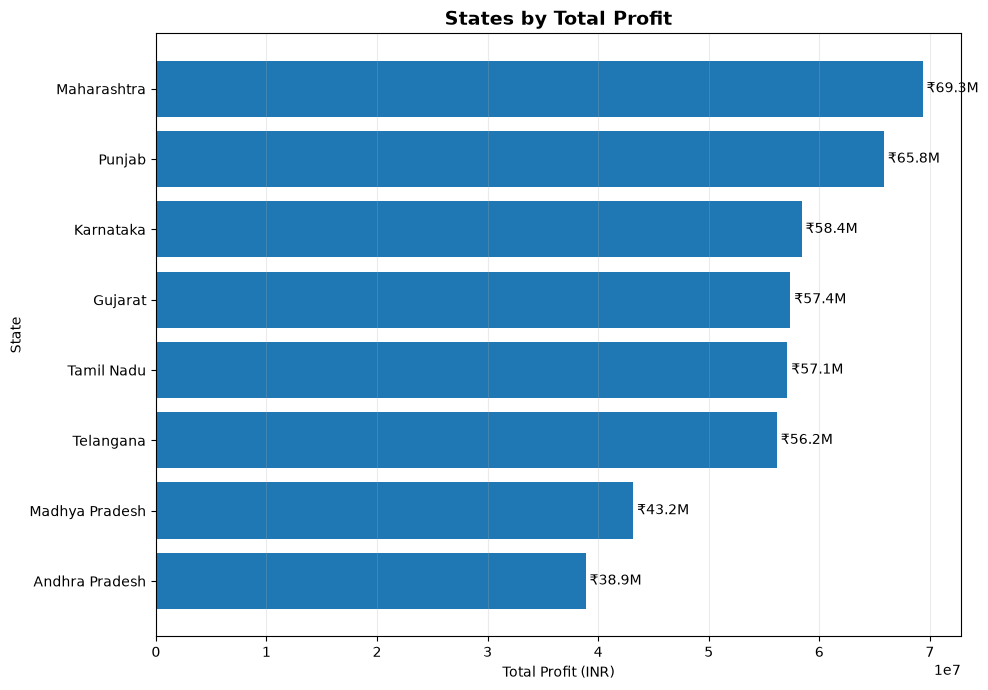

In [39]:
# 10. STATE-WISE ANALYSIS
state_kpi = (
    data.groupby("State", dropna=False)
    .agg(
        Records=("Farm_ID", "count"),
        Avg_Yield=("Yield_Tonnes_Ha", "mean"),
        Total_Production=("Production_Tonnes", "sum"),
        Total_Revenue=("Revenue_INR", "sum"),
        Total_Cost=("Total_Cost_INR", "sum"),
        Total_Profit=("Profit_INR", "sum"),
        Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
        Avg_Risk=("Disease_Pest_Risk_pct", "mean")
    )
    .reset_index()
)

state_kpi["Profit_Margin_pct"] = np.where(
    state_kpi["Total_Revenue"].ne(0),
    state_kpi["Total_Profit"] / state_kpi["Total_Revenue"] * 100,
    np.nan
)

state_kpi = state_kpi.sort_values("Total_Profit", ascending=False).reset_index(drop=True)

display(state_kpi.round(2))

top_states = state_kpi.head(12).sort_values("Total_Profit")

plt.figure(figsize=(10, 7))
bars = plt.barh(top_states["State"], top_states["Total_Profit"])
plt.title("States by Total Profit", fontsize=14, fontweight="bold")
plt.xlabel("Total Profit (INR)")
plt.ylabel("State")
plt.grid(axis="x", alpha=0.25)

for bar, value in zip(bars, top_states["Total_Profit"]):
    plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
             f" ₹{value/1e6:.1f}M", va="center")

plt.tight_layout()
plt.savefig(CHART_DIR / "05_states_profit.png", dpi=160, bbox_inches="tight")
plt.show()
plt.close()

## 11. Environmental Analysis

,Yield_Tonnes_Ha,Profit_INR,Production_Tonnes
Rainfall_mm,0.03,0.11,0.02
Avg_Temperature_C,0.01,0.01,0.01
Humidity_pct,0.01,0.06,0.00
Sunlight_Hours_Day,-0.01,-0.06,-0.02
Soil_pH,-0.02,-0.01,-0.01
Soil_Moisture_pct,0.01,0.09,0.01


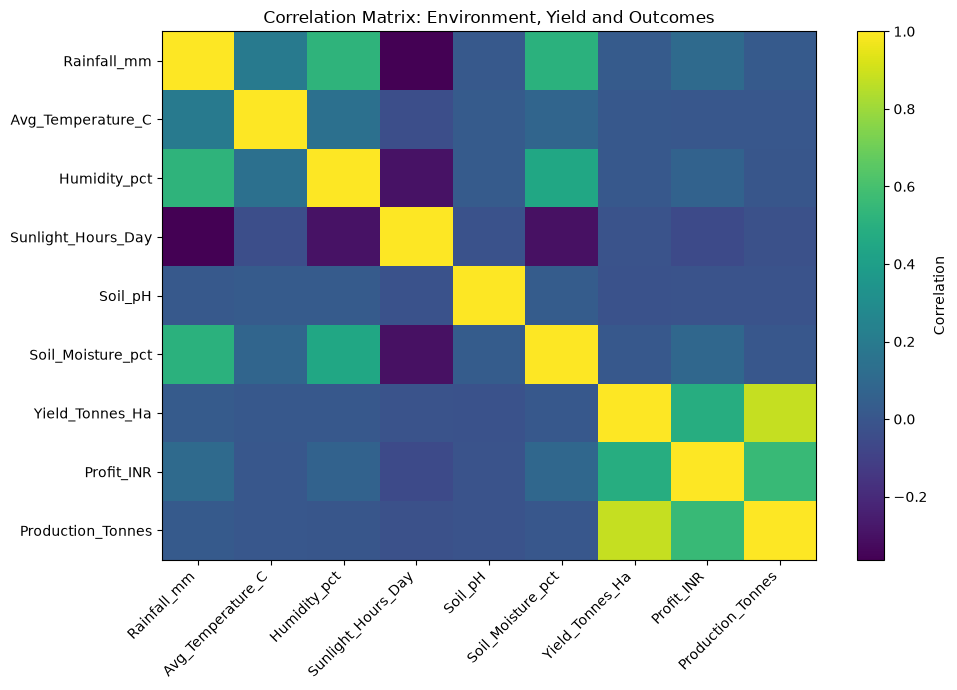

In [40]:
# 11. ENVIRONMENTAL RELATIONSHIPS
environmental = [
    "Rainfall_mm", "Avg_Temperature_C", "Humidity_pct",
    "Sunlight_Hours_Day", "Soil_pH", "Soil_Moisture_pct"
]

targets = ["Yield_Tonnes_Ha", "Profit_INR", "Production_Tonnes"]

environmental = [c for c in environmental if c in data.columns]
targets = [c for c in targets if c in data.columns]

env_corr = data[environmental + targets].corr(numeric_only=True)
display(env_corr.loc[environmental, targets].round(3))

plt.figure(figsize=(10, 7))
plt.imshow(env_corr, aspect="auto", interpolation="nearest")
plt.colorbar(label="Correlation")
plt.xticks(range(len(env_corr.columns)), env_corr.columns, rotation=45, ha="right")
plt.yticks(range(len(env_corr.index)), env_corr.index)
plt.title("Correlation Matrix: Environment, Yield and Outcomes")
plt.tight_layout()
plt.savefig(CHART_DIR / "06_environment_correlation_heatmap.png", dpi=160, bbox_inches="tight")
plt.show()
plt.close()

Pearson regression r=0.031, p=0.050304


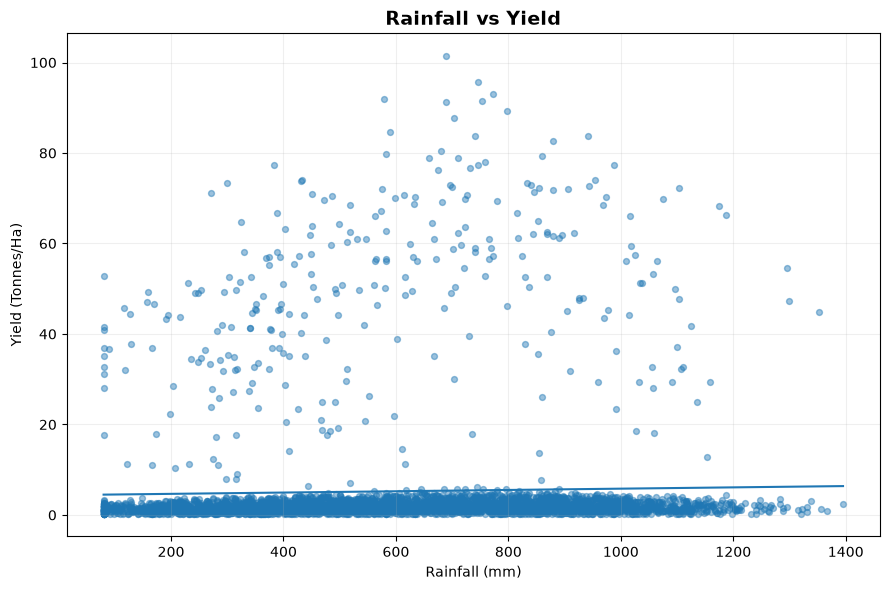

In [41]:
# 12. RAINFALL VS YIELD
plot = data[["Rainfall_mm", "Yield_Tonnes_Ha"]].dropna()

plt.figure(figsize=(9, 6))
plt.scatter(plot["Rainfall_mm"], plot["Yield_Tonnes_Ha"], alpha=0.45, s=18)

# Regression line only when enough variation exists
if len(plot) >= 2 and plot["Rainfall_mm"].nunique() > 1:
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        plot["Rainfall_mm"], plot["Yield_Tonnes_Ha"]
    )
    x_line = np.linspace(plot["Rainfall_mm"].min(), plot["Rainfall_mm"].max(), 100)
    plt.plot(x_line, intercept + slope * x_line)
    print(f"Pearson regression r={r_value:.3f}, p={p_value:.6f}")

plt.title("Rainfall vs Yield", fontsize=14, fontweight="bold")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(CHART_DIR / "07_rainfall_vs_yield.png", dpi=160, bbox_inches="tight")
plt.show()
plt.close()

## 13. Resource and Irrigation Analysis

In [42]:
# 13. RESOURCE UTILIZATION
resource_cols = [
    "Nitrogen_kg_ha", "Phosphorus_kg_ha", "Potassium_kg_ha",
    "Fertilizer_kg_ha", "Pesticide_Litre_ha", "Water_Used_m3",
    "Water_Efficiency_t_per_1000m3", "Seed_Quality_Score"
]
resource_cols = [c for c in resource_cols if c in data.columns]

resource_corr = data[resource_cols + ["Yield_Tonnes_Ha"]].corr(numeric_only=True)["Yield_Tonnes_Ha"]
resource_corr = resource_corr.sort_values(ascending=False).to_frame("Correlation_with_Yield")
display(resource_corr)

irrigation = (
    data.groupby("Irrigation_Method")
    .agg(
        Records=("Farm_ID", "count"),
        Avg_Yield=("Yield_Tonnes_Ha", "mean"),
        Avg_Water_Used=("Water_Used_m3", "mean"),
        Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
        Avg_Profit=("Profit_INR", "mean")
    )
    .reset_index()
    .sort_values("Avg_Water_Efficiency", ascending=False)
)

display(irrigation.round(2))

,Correlation_with_Yield
Yield_Tonnes_Ha,1.00
Water_Efficiency_t_per_1000m3,0.91
Water_Used_m3,0.39
Nitrogen_kg_ha,0.05
Phosphorus_kg_ha,0.05
Potassium_kg_ha,0.00
Fertilizer_kg_ha,0.00
Seed_Quality_Score,-0.01
Pesticide_Litre_ha,-0.01


,Irrigation_Method,Records,Avg_Yield,Avg_Water_Used,Avg_Water_Efficiency,Avg_Profit
2,Rainfed,1041,4.60,"3,549.55",7.56,"79,050.37"
0,Drip,915,6.58,"5,918.75",6.27,"219,626.00"
3,Sprinkler,734,5.16,"6,208.26",4.67,"91,121.08"
1,Flood,1310,4.86,"8,026.47",3.44,"73,354.02"


## 14. Economic Performance

Economic descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
Market_Price_INR_Tonne,"4,000.00","44,714.17","30,266.16","2,594.00","21,429.25","25,913.00","68,279.00","131,240.00"
Total_Cost_INR,"4,000.00","526,303.58","294,419.14","26,826.00","274,577.50","519,082.50","761,996.50","1,349,990.00"
Revenue_INR,"4,000.00","637,860.05","636,974.71","6,107.00","207,517.25","456,830.50","836,874.75","5,080,900.00"
Profit_INR,"4,000.00","111,556.46","545,081.89","-1,019,223.00","-148,731.75","3,673.00","216,187.75","4,345,421.00"
Profit_Margin_pct,"4,000.00",-45.49,158.09,"-1,461.85",-60.19,1.15,32.89,85.92


Season-wise economic performance:


,Season,Avg_Market_Price,Total_Cost,Total_Revenue,Total_Profit,Avg_Profit_Margin
0,Kharif,"44,850.91",946080042,1264369200,318289158,-38.64
1,Rabi,"44,747.97",836012113,978682881,142670768,-44.27
2,Zaid,"44,212.03",323122177,308388111,-14734066,-69.35


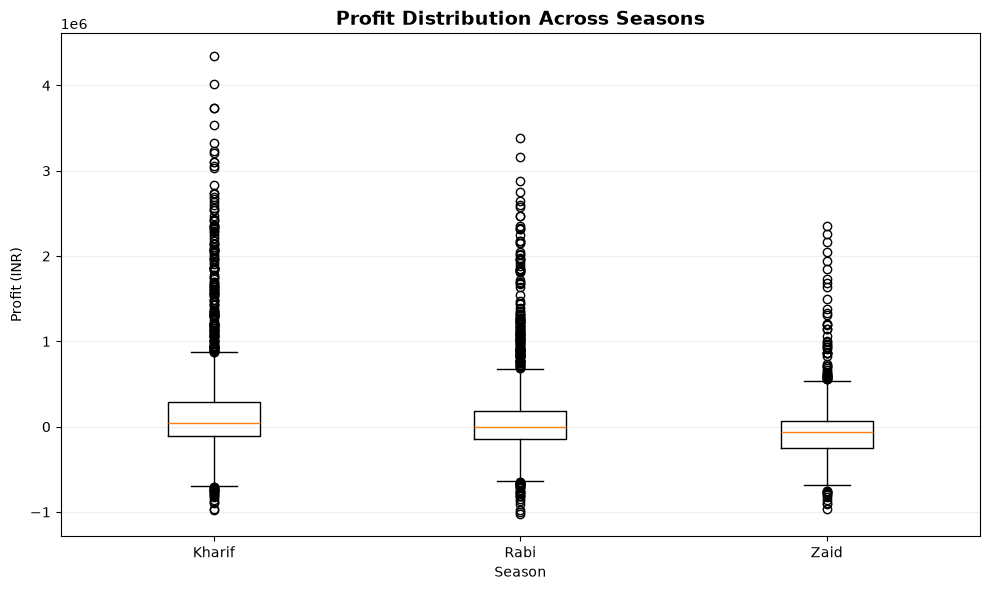

Profit distribution graph created successfully.


In [43]:
# 14. ECONOMIC ANALYSIS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Select economic columns
economic = data[
    [
        "Season",
        "Crop",
        "Market_Price_INR_Tonne",
        "Total_Cost_INR",
        "Revenue_INR",
        "Profit_INR"
    ]
].copy()

# Ensure numeric columns are numeric
economic_numeric_cols = [
    "Market_Price_INR_Tonne",
    "Total_Cost_INR",
    "Revenue_INR",
    "Profit_INR"
]

for col in economic_numeric_cols:
    economic[col] = pd.to_numeric(
        economic[col],
        errors="coerce"
    )

# Profit Margin
economic["Profit_Margin_pct"] = np.where(
    economic["Revenue_INR"].notna() &
    economic["Revenue_INR"].ne(0),
    (economic["Profit_INR"] / economic["Revenue_INR"]) * 100,
    np.nan
)

# Descriptive Statistics
print("Economic descriptive statistics:")

display(
    economic[
        [
            "Market_Price_INR_Tonne",
            "Total_Cost_INR",
            "Revenue_INR",
            "Profit_INR",
            "Profit_Margin_pct"
        ]
    ]
    .describe()
    .T
    .round(2)
)

# Season-wise Economic Analysis
economic_season = (
    economic
    .dropna(subset=["Season"])
    .groupby("Season")
    .agg(
        Avg_Market_Price=(
            "Market_Price_INR_Tonne",
            "mean"
        ),

        Total_Cost=(
            "Total_Cost_INR",
            "sum"
        ),

        Total_Revenue=(
            "Revenue_INR",
            "sum"
        ),

        Total_Profit=(
            "Profit_INR",
            "sum"
        ),

        Avg_Profit_Margin=(
            "Profit_Margin_pct",
            "mean"
        )
    )
    .reset_index()
    .sort_values(
        "Total_Profit",
        ascending=False
    )
)

print("Season-wise economic performance:")

display(
    economic_season.round(2)
)

# Profit Distribution Across Seasons
seasons = (
    data["Season"]
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
    .tolist()
)

groups = []

valid_seasons = []

for season in seasons:

    values = pd.to_numeric(
        data.loc[
            data["Season"] == season,
            "Profit_INR"
        ],
        errors="coerce"
    ).dropna().values

    if len(values) > 0:
        groups.append(values)
        valid_seasons.append(season)

if len(groups) > 0:

    fig, ax = plt.subplots(
        figsize=(10, 6)
    )

    ax.boxplot(
        groups,
        tick_labels=valid_seasons,
        patch_artist=False
    )

    ax.set_title(
        "Profit Distribution Across Seasons",
        fontsize=14,
        fontweight="bold"
    )

    ax.set_xlabel(
        "Season"
    )

    ax.set_ylabel(
        "Profit (INR)"
    )

    ax.grid(
        axis="y",
        alpha=0.2
    )

    plt.tight_layout()

    # Save chart
    CHART_DIR.mkdir(
        parents=True,
        exist_ok=True
    )

    plt.savefig(
        CHART_DIR /
        "08_profit_distribution_season.png",
        dpi=160,
        bbox_inches="tight"
    )

    plt.show()

    plt.close()

    print("Profit distribution graph created successfully.")

else:

    print(
        "No valid Profit_INR data available for boxplot."
    )

## 15. Disease / Pest Risk Analysis

,Season,Avg_Risk,Avg_Yield,Avg_Profit
0,Kharif,54.47,5.63,"178,914.65"
1,Rabi,40.48,5.04,"87,689.47"
2,Zaid,38.22,4.64,"-24,804.82"


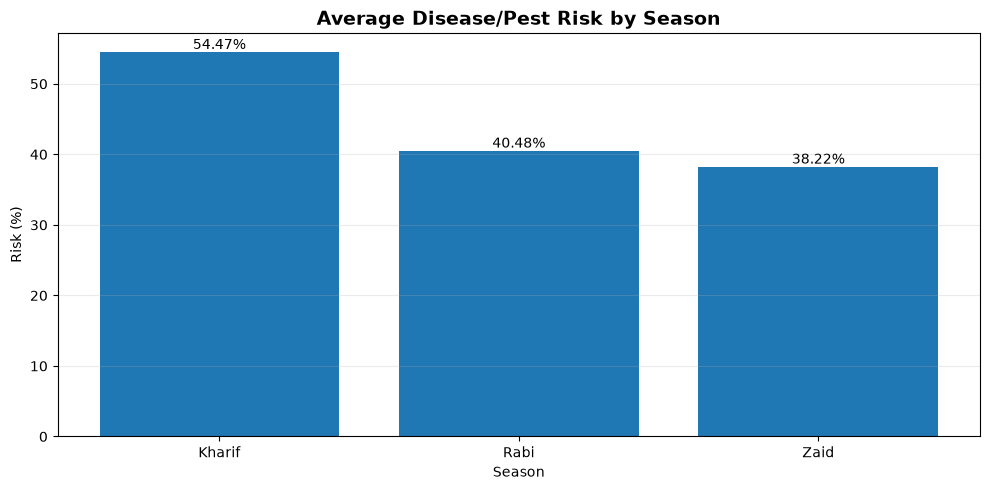

In [44]:
# 15. RISK ANALYSIS
risk = (
    data.groupby("Season")
    .agg(
        Avg_Risk=("Disease_Pest_Risk_pct", "mean"),
        Avg_Yield=("Yield_Tonnes_Ha", "mean"),
        Avg_Profit=("Profit_INR", "mean")
    )
    .reset_index()
    .sort_values("Avg_Risk", ascending=False)
)

display(risk.round(2))

plt.figure(figsize=(10, 5))
bars = plt.bar(risk["Season"], risk["Avg_Risk"])
plt.title("Average Disease/Pest Risk by Season", fontsize=14, fontweight="bold")
plt.xlabel("Season")
plt.ylabel("Risk (%)")
plt.grid(axis="y", alpha=0.25)

for bar, value in zip(bars, risk["Avg_Risk"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f"{value:.2f}%", ha="center", va="bottom")

plt.tight_layout()
plt.savefig(CHART_DIR / "09_risk_by_season.png", dpi=160, bbox_inches="tight")
plt.show()
plt.close()


## 16. Statistical Analysis

In [45]:
# 16. SPEARMAN CORRELATION SIGNIFICANCE
rows = []

for col in data.select_dtypes(include=np.number).columns:
    if col == "Yield_Tonnes_Ha":
        continue

    valid = data[[col, "Yield_Tonnes_Ha"]].dropna()

    if len(valid) >= 3 and valid[col].nunique() > 1 and valid["Yield_Tonnes_Ha"].nunique() > 1:
        r, p = stats.spearmanr(valid[col], valid["Yield_Tonnes_Ha"])
        rows.append([
            col, r, p,
            "Significant" if p < 0.05 else "Not significant"
        ])

corr_sig = pd.DataFrame(
    rows,
    columns=["Variable", "Spearman_r", "p_value", "Interpretation"]
).sort_values("p_value")

display(corr_sig.round(4))

,Variable,Spearman_r,p_value,Interpretation
13,Production_Tonnes,0.74,0.00,Significant
14,Market_Price_INR_Tonne,-0.58,0.00,Significant
19,Water_Efficiency_t_per_1000m3,0.74,0.00,Significant
17,Profit_INR,0.49,0.00,Significant
16,Revenue_INR,0.41,0.00,Significant
18,Water_Used_m3,0.26,0.00,Significant
1,Rainfall_mm,0.13,0.00,Significant
6,Soil_Moisture_pct,0.10,0.00,Significant
7,Nitrogen_kg_ha,0.08,0.00,Significant
3,Humidity_pct,0.08,0.00,Significant


In [46]:
# 17. ONE-WAY ANOVA: YIELD ACROSS SEASONS
groups = [
    group["Yield_Tonnes_Ha"].dropna().values
    for _, group in data.groupby("Season")
    if len(group["Yield_Tonnes_Ha"].dropna()) >= 2
]

if len(groups) >= 2:
    f_stat, p_val = stats.f_oneway(*groups)

    print(f"One-way ANOVA: F = {f_stat:.3f}, p = {p_val:.6f}")

    if p_val < 0.05:
        print("Interpretation: Yield differs significantly across at least some seasons (p < 0.05).")
    else:
        print("Interpretation: No statistically significant seasonal yield difference detected (p >= 0.05).")
else:
    print("ANOVA could not be performed because fewer than two valid season groups were available.")

One-way ANOVA: F = 1.544, p = 0.213678
Interpretation: No statistically significant seasonal yield difference detected (p >= 0.05).


## 18. Outlier Analysis

In [47]:
# 18. IQR OUTLIER DETECTION
outlier_rows = []

for col in data.select_dtypes(include=np.number).columns:
    series = data[col].dropna()

    if series.empty:
        continue

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    if iqr == 0:
        lower, upper = q1, q3
    else:
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

    count = int(((series < lower) | (series > upper)).sum())

    outlier_rows.append([
        col, lower, upper, count, count / len(series) * 100
    ])

outliers = pd.DataFrame(
    outlier_rows,
    columns=["Variable", "Lower_Bound", "Upper_Bound", "Outlier_Count", "Outlier_pct"]
).sort_values("Outlier_Count", ascending=False)

display(outliers.round(2))

,Variable,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_pct
18,Profit_INR,"-696,111.00","763,567.00",404,10.10
14,Production_Tonnes,-23.98,53.36,333,8.33
20,Water_Efficiency_t_per_1000m3,-3.57,10.38,322,8.05
13,Yield_Tonnes_Ha,-1.62,5.50,302,7.55
19,Water_Used_m3,"-6,072.75","16,171.25",276,6.90
17,Revenue_INR,"-736,519.00","1,780,911.00",240,6.00
9,Potassium_kg_ha,30.10,179.70,32,0.80
4,Sunlight_Hours_Day,4.35,10.35,26,0.65
8,Phosphorus_kg_ha,11.40,104.20,16,0.40
10,Fertilizer_kg_ha,19.14,352.04,15,0.38


## 19. Key Findings

In [48]:
# 19. AUTOMATIC KEY FINDINGS
best_yield_season = season_kpi.loc[season_kpi["Avg_Yield"].idxmax()]
best_profit_season = season_kpi.loc[season_kpi["Total_Profit"].idxmax()]
best_yield_crop = crop_kpi.loc[crop_kpi["Avg_Yield"].idxmax()]
best_profit_crop = crop_kpi.loc[crop_kpi["Total_Profit"].idxmax()]
best_profit_state = state_kpi.loc[state_kpi["Total_Profit"].idxmax()]
best_water_method = irrigation.loc[irrigation["Avg_Water_Efficiency"].idxmax()]

print("=" * 70)
print("KEY FINDINGS")
print("=" * 70)

print(
    f"1. Highest average-yield season: {best_yield_season['Season']} "
    f"({best_yield_season['Avg_Yield']:.2f} tonnes/ha)."
)

print(
    f"2. Highest total-profit season: {best_profit_season['Season']} "
    f"(₹{best_profit_season['Total_Profit']:,.0f})."
)

print(
    f"3. Highest average-yield crop: {best_yield_crop['Crop']} "
    f"({best_yield_crop['Avg_Yield']:.2f} tonnes/ha)."
)

print(
    f"4. Highest total-profit crop: {best_profit_crop['Crop']} "
    f"(₹{best_profit_crop['Total_Profit']:,.0f})."
)

print(
    f"5. Highest total-profit state: {best_profit_state['State']} "
    f"(₹{best_profit_state['Total_Profit']:,.0f})."
)

print(
    f"6. Most water-efficient irrigation method: {best_water_method['Irrigation_Method']} "
    f"({best_water_method['Avg_Water_Efficiency']:.2f} tonnes/1000m³)."
)

print(
    f"7. Dataset contains {len(data):,} cleaned records across "
    f"{data['Season'].nunique()} seasons, {data['Crop'].nunique()} crops and "
    f"{data['State'].nunique()} states."
)

print("=" * 70)

KEY FINDINGS
1. Highest average-yield season: Kharif (5.63 tonnes/ha).
2. Highest total-profit season: Kharif (₹318,289,158).
3. Highest average-yield crop: Sugarcane (46.64 tonnes/ha).
4. Highest total-profit crop: Chilli (₹309,361,877).
5. Highest total-profit state: Maharashtra (₹69,339,574).
6. Most water-efficient irrigation method: Rainfed (7.56 tonnes/1000m³).
7. Dataset contains 4,000 cleaned records across 3 seasons, 8 crops and 8 states.


## 20. Evidence-based Recommendations

In [49]:
# 20. RECOMMENDATIONS
recommendations = [
    f"Prioritize planning and resource allocation for {best_yield_season['Season']}, "
    f"which has the highest average yield in the dataset.",

    f"Evaluate {best_profit_crop['Crop']} for economically focused crop planning because it "
    f"has the highest total profit in the dataset.",

    f"Use {best_yield_crop['Crop']} as a high-productivity crop candidate, while separately "
    f"checking market price, production cost and profit before making a final crop decision.",

    f"Study the practices and conditions associated with {best_profit_state['State']}, "
    f"the highest-profit state, and compare them with lower-performing regions.",

    f"Consider the resource profile of {best_water_method['Irrigation_Method']} when planning "
    f"water-efficient operations, while also checking yield and profitability together.",

    "Monitor disease/pest risk by season and combine risk information with environmental "
    "conditions before seasonal planning.",

    "Use statistical relationships as evidence of association rather than assuming that "
    "correlation alone proves causation."
]

for i, rec in enumerate(recommendations, 1):
    print(f"{i}. {rec}")

1. Prioritize planning and resource allocation for Kharif, which has the highest average yield in the dataset.
2. Evaluate Chilli for economically focused crop planning because it has the highest total profit in the dataset.
3. Use Sugarcane as a high-productivity crop candidate, while separately checking market price, production cost and profit before making a final crop decision.
4. Study the practices and conditions associated with Maharashtra, the highest-profit state, and compare them with lower-performing regions.
5. Consider the resource profile of Rainfed when planning water-efficient operations, while also checking yield and profitability together.
6. Monitor disease/pest risk by season and combine risk information with environmental conditions before seasonal planning.
7. Use statistical relationships as evidence of association rather than assuming that correlation alone proves causation.


## 21. Final Conclusion

In [50]:
# 21. FINAL CONCLUSION
print(
    f"The analysis of {len(data):,} agricultural records shows meaningful variation "
    f"across {data['Season'].nunique()} seasons, {data['Crop'].nunique()} crops and "
    f"{data['State'].nunique()} states. "
    f"{best_yield_season['Season']} records the highest average yield, while "
    f"{best_profit_season['Season']} records the highest total profit. "
    f"At crop level, {best_yield_crop['Crop']} has the highest average yield, whereas "
    f"{best_profit_crop['Crop']} generates the highest total profit. "
    f"The analysis also shows that environmental conditions, resource usage, irrigation, "
    f"risk and economic factors should be considered together rather than using yield alone. "
    f"Overall, the findings provide an evidence-based foundation for seasonal planning, "
    f"resource allocation, crop selection and risk-aware agricultural decision making."
)

The analysis of 4,000 agricultural records shows meaningful variation across 3 seasons, 8 crops and 8 states. Kharif records the highest average yield, while Kharif records the highest total profit. At crop level, Sugarcane has the highest average yield, whereas Chilli generates the highest total profit. The analysis also shows that environmental conditions, resource usage, irrigation, risk and economic factors should be considered together rather than using yield alone. Overall, the findings provide an evidence-based foundation for seasonal planning, resource allocation, crop selection and risk-aware agricultural decision making.


## 22. Export Cleaned Dataset and Summary Tables

In [51]:
# 22. EXPORT ALL IMPORTANT OUTPUTS
data.to_csv("cleaned_agriculture_data.csv", index=False)

season_kpi.to_csv("season_summary.csv", index=False)
crop_kpi.to_csv("crop_summary.csv", index=False)
state_kpi.to_csv("state_summary.csv", index=False)
irrigation.to_csv("irrigation_summary.csv", index=False)
economic_season.to_csv("economic_season_summary.csv", index=False)
risk.to_csv("season_risk_summary.csv", index=False)
corr_sig.to_csv("yield_correlation_significance.csv", index=False)
outliers.to_csv("outlier_summary.csv", index=False)

print("Export completed successfully.")
print("Cleaned dataset:","cleaned_agriculture_data.csv")
print("Summary tables:", TABLE_DIR)
print("Charts:", CHART_DIR)

Export completed successfully.
Cleaned dataset: cleaned_agriculture_data.csv
Summary tables: C:\Users\Admin\h\outputs\summary_tables
Charts: C:\Users\Admin\h\outputs\charts
